In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('survey.csv')
data.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [3]:
data.shape


(73268, 79)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

In [5]:
df = data[['Country','EdLevel','YearsCodePro','Employment','ConvertedCompYearly']]

In [6]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Employment',
       'ConvertedCompYearly'],
      dtype='object')

In [7]:
df.isnull().sum()

Country                 1497
EdLevel                 1697
YearsCodePro           21435
Employment              1559
ConvertedCompYearly    35197
dtype: int64

In [8]:
df = df.rename({'ConvertedCompYearly':'Salary'},axis=1)

In [9]:
df = df[df['Salary'].notnull()]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
2,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,"Employed, full-time",40205.0
3,Israel,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,"Employed, full-time",215232.0
8,Netherlands,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,"Employed, full-time",49056.0
10,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,"Employed, full-time",60307.0
11,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10,"Employed, full-time;Independent contractor, fr...",194400.0


In [10]:
df.isnull().sum()

Country           0
EdLevel          17
YearsCodePro    136
Employment        4
Salary            0
dtype: int64

In [11]:
df=df.dropna()

In [12]:
df.isnull().sum()

Country         0
EdLevel         0
YearsCodePro    0
Employment      0
Salary          0
dtype: int64

In [13]:
df['Employment'].value_counts()

Employment
Employed, full-time                                                                             31382
Independent contractor, freelancer, or self-employed                                             2739
Employed, full-time;Independent contractor, freelancer, or self-employed                         2633
Employed, part-time                                                                               632
Independent contractor, freelancer, or self-employed;Employed, part-time                          207
Employed, full-time;Employed, part-time                                                           151
Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time      118
I prefer not to say                                                                                27
Retired                                                                                            18
Employed, part-time;Retired                                            

In [14]:
shaped=df[df['Employment']=='Employed, full-time']
shaped.shape

(31382, 5)

In [15]:
df = shaped.drop('Employment',axis=1)

In [16]:
df.head()

,Country,EdLevel,YearsCodePro,Salary
2,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5,40205.0
3,Israel,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17,215232.0
8,Netherlands,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6,49056.0
10,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,60307.0
12,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,65000.0


In [17]:
df['Country'].value_counts()

Country
United States of America                                7858
Germany                                                 2382
United Kingdom of Great Britain and Northern Ireland    2341
India                                                   1869
Canada                                                  1249
                                                        ... 
Haiti                                                      1
Zambia                                                     1
Suriname                                                   1
Somalia                                                    1
Seychelles                                                 1
Name: count, Length: 155, dtype: int64

In [18]:
def digest_catgories(catgories, cutoff):
    catgoricalMap = {}

    for i in range(len(catgories)):
        if catgories.values[i] >= cutoff:
            catgoricalMap[catgories.index[i]] = catgories.index[i]
        else:
            catgoricalMap[catgories.index[i]] = 'Other'

    return catgoricalMap

In [19]:
countryMap = digest_catgories(df.Country.value_counts(),500)
print(countryMap)

{'United States of America': 'United States of America', 'Germany': 'Germany', 'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom of Great Britain and Northern Ireland', 'India': 'India', 'Canada': 'Canada', 'France': 'France', 'Brazil': 'Brazil', 'Spain': 'Spain', 'Netherlands': 'Netherlands', 'Australia': 'Australia', 'Italy': 'Italy', 'Poland': 'Poland', 'Sweden': 'Sweden', 'Russian Federation': 'Other', 'Switzerland': 'Other', 'Turkey': 'Other', 'Israel': 'Other', 'Austria': 'Other', 'Norway': 'Other', 'Portugal': 'Other', 'Denmark': 'Other', 'Belgium': 'Other', 'Finland': 'Other', 'Mexico': 'Other', 'New Zealand': 'Other', 'Greece': 'Other', 'South Africa': 'Other', 'Pakistan': 'Other', 'Czech Republic': 'Other', 'Iran, Islamic Republic of...': 'Other', 'Argentina': 'Other', 'Romania': 'Other', 'Ireland': 'Other', 'Ukraine': 'Other', 'Hungary': 'Other', 'Japan': 'Other', 'Bangladesh': 'Other', 'Colombia': 'Other', 'China': 'Other', 'Bulgaria': 'Other', 'Indone

In [20]:
df.Country = df['Country'].map(countryMap)

In [21]:
df.Country.value_counts()

Country
Other                                                   9484
United States of America                                7858
Germany                                                 2382
United Kingdom of Great Britain and Northern Ireland    2341
India                                                   1869
Canada                                                  1249
France                                                  1126
Brazil                                                  1014
Spain                                                    858
Netherlands                                              701
Australia                                                700
Italy                                                    667
Poland                                                   572
Sweden                                                   561
Name: count, dtype: int64

In [22]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Salary'], dtype='object')

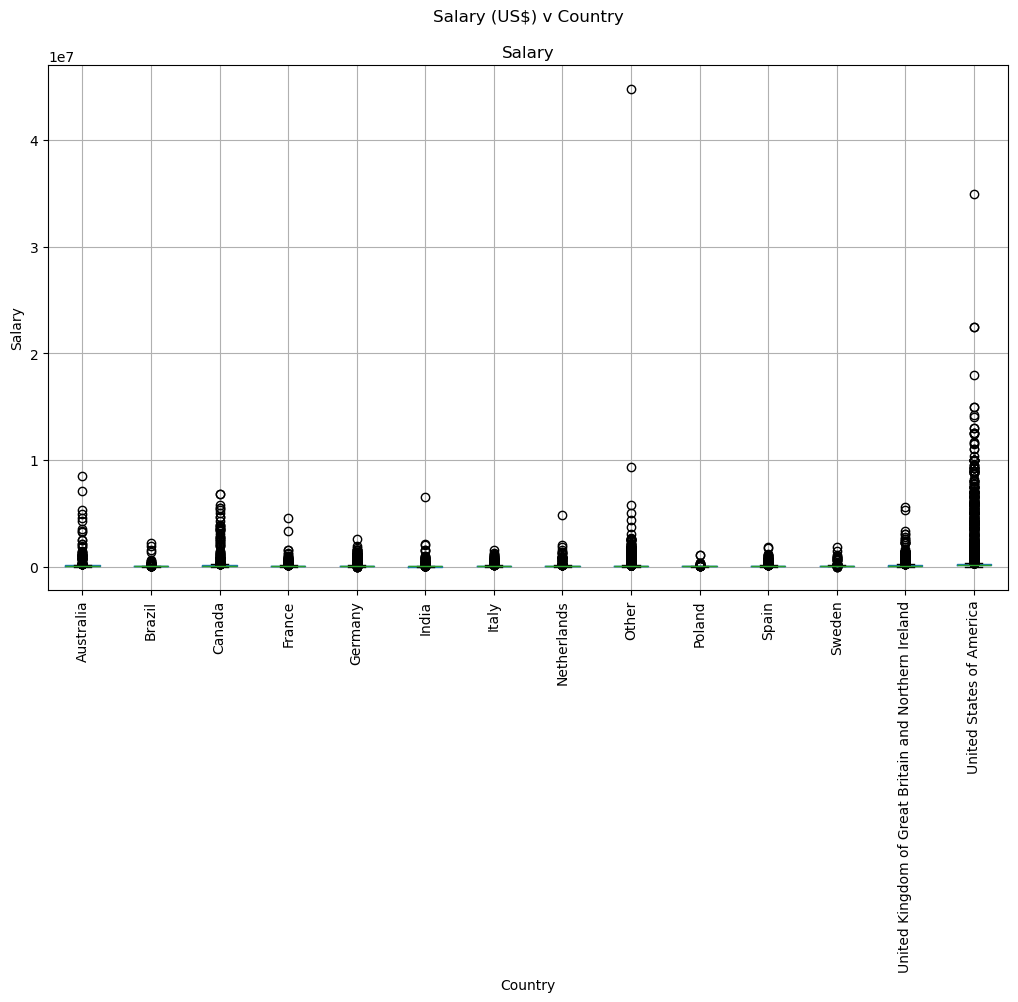

In [23]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
df.boxplot('Salary','Country',ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

In [24]:
df = df[df['Salary'] <= 250000]
df = df[df['Salary'] > 10000]
df = df[df['Country'] != 'Other']

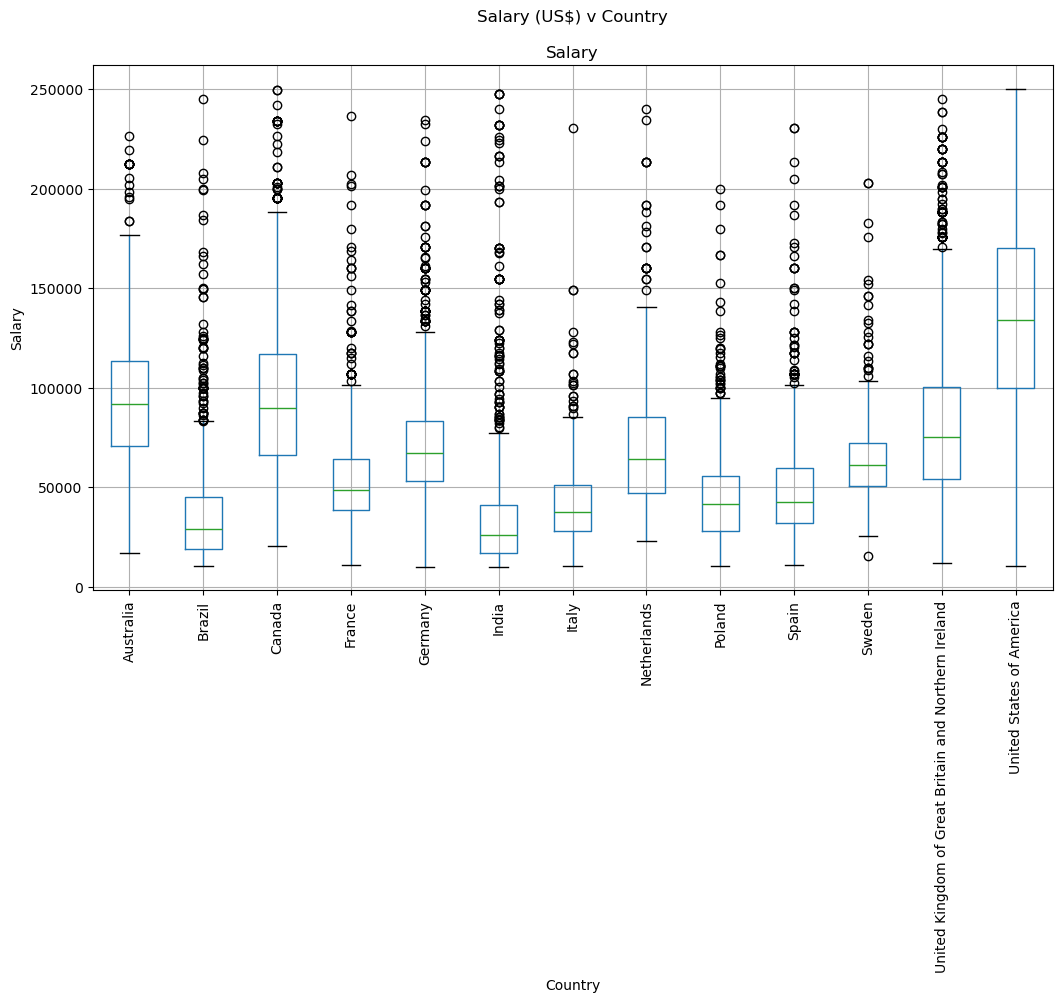

In [25]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
df.boxplot('Salary','Country',ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

In [26]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Salary'], dtype='object')

In [27]:
df.YearsCodePro.unique()

array(['5', '6', '2', '4', '20', '9', '14', '21', '15', '25', '3', '10',
       '8', '12', '7', '19', '17', '24', '1', '11', '23',
       'Less than 1 year', '18', '37', '46', '22', '32', '13', '27', '28',
       '16', '31', '34', '35', '26', '42', '38', '30', '36', '40', '41',
       '29', '33', '39', '48', '45', '44', '43', 'More than 50 years',
       '47', '49', '50'], dtype=object)

In [28]:
def setExperience(i):
    if i == 'More than 50 years':
        return 50
    if i == 'Less than 1 year':
        return 0.5
    return float(i)    

In [29]:
df['YearsCodePro'] = df['YearsCodePro'].apply(setExperience)

In [30]:
df['YearsCodePro'].unique()

array([ 5. ,  6. ,  2. ,  4. , 20. ,  9. , 14. , 21. , 15. , 25. ,  3. ,
       10. ,  8. , 12. ,  7. , 19. , 17. , 24. ,  1. , 11. , 23. ,  0.5,
       18. , 37. , 46. , 22. , 32. , 13. , 27. , 28. , 16. , 31. , 34. ,
       35. , 26. , 42. , 38. , 30. , 36. , 40. , 41. , 29. , 33. , 39. ,
       48. , 45. , 44. , 43. , 50. , 47. , 49. ])

In [31]:
df.columns

Index(['Country', 'EdLevel', 'YearsCodePro', 'Salary'], dtype='object')

In [32]:
df.EdLevel.unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)', 'Something else',
       'Associate degree (A.A., A.S., etc.)',
       'Some college/university study without earning a degree',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Professional degree (JD, MD, etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'Primary/elementary school'], dtype=object)

In [33]:
def setEducation(i):
    if 'Master’s degree' in i:
        return 'Master’s degree'
    if 'Bachelor’s degree' in i:
        return 'Bachelor’s degree'
    if 'Professional degree' in i or 'Other doctoral degree' in i:
        return 'Post gard'
    return 'Less than a Bachelors'

In [34]:
df['EdLevel'] = df['EdLevel'].apply(setEducation)

In [35]:
df.EdLevel.unique()

array(['Master’s degree', 'Bachelor’s degree', 'Less than a Bachelors',
       'Post gard'], dtype=object)

In [36]:
from sklearn.preprocessing import LabelEncoder

In [38]:
leEducation =LabelEncoder()
df['EdLevel'] = leEducation.fit_transform(df['EdLevel'])

In [39]:
df.EdLevel.unique()

array([2, 0, 1, 3])

In [40]:
leCountry = LabelEncoder()
df['Country'] = leCountry.fit_transform(df['Country'])

In [41]:
df.Country.unique()

array([11,  7, 12,  6,  2,  4,  8,  3,  1, 10,  9,  5,  0])

### Model Bulding

In [44]:
X = df.drop('Salary',axis=1)
y = df['Salary']

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model_lr = LinearRegression()
model_lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = model_lr.predict(X)

In [48]:
print(y_pred)

[98233.6618493  77104.27452007 95314.55879151 ... 99161.8236174
 83793.14378928 94406.77649886]


In [50]:
from sklearn.metrics import mean_squared_error

In [51]:
errorRate = np.sqrt(mean_squared_error(y,y_pred))
print(errorRate)

45306.67322421268


### try Diffrent Algorithms

##### Decision tree

In [52]:
from sklearn.tree import DecisionTreeRegressor

In [54]:
model_dt= DecisionTreeRegressor(random_state=0)
model_dt.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [55]:
y_pred = model_dt.predict(X)

In [56]:
errorRateDt = np.sqrt(mean_squared_error(y,y_pred))
print(errorRateDt)

33869.99548582426


#### RandomForest

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [58]:
model_rf = RandomForestRegressor(random_state=0)
model_rf.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
y_pred = model_rf.predict(X)

In [60]:
errorRateRf = np.sqrt(mean_squared_error(y,y_pred))
print(errorRateRf)

33943.451561151516


#### GridSearchCV

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
max_depth = [None,2,4,6,8,10,12,14,16]
parameters = {'max_depth':max_depth}

In [64]:
model_df2 =  DecisionTreeRegressor(random_state=0)
gs = GridSearchCV(model_df2,parameters,scoring='neg_mean_squared_error')
gs.fit(X,y)

,estimator,DecisionTreeR...andom_state=0)
,param_grid,"{'max_depth': [None, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [67]:
model_df3 = gs.best_estimator_

In [68]:
model_df3.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
y_predict = model_df3.predict(X)

In [71]:
errorRate = np.sqrt(mean_squared_error(y,y_predict))
print(errorRate)

35074.748537535896


In [72]:
X

,Country,EdLevel,YearsCodePro
2,11,2,5.0
8,7,2,6.0
10,11,0,2.0
12,12,0,5.0
21,6,2,4.0
...,...,...,...
73113,12,2,5.0
73116,12,0,16.0
73119,12,0,1.0
73120,9,0,2.0


In [83]:
p = np.array([['Germany','Master’s degree','4']])
p

array([['Germany', 'Master’s degree', '4']], dtype='<U15')

In [84]:
p[:,0]=leCountry.transform(p[:,0])
p[:,1]=leEducation.transform(p[:,1])
p = p.astype(float)

In [85]:
p

array([[4., 2., 4.]])

In [86]:
y_pred = model_dt.predict(p)
y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([67305.55932203])

##### Model Saving

In [87]:
data = {'model':model_dt,'leCountry':leCountry,'leEducation':leEducation}

In [88]:
import pickle

In [89]:
with open('saveModel.pkl','wb') as file:
    pickle.dump(data,file)

In [90]:
with open('saveModel.pkl','rb') as out:
    data = pickle.load(out)

In [91]:
model_loaded = data['model']
leCountry = data['leCountry']
leEducation = data['leEducation']

In [92]:
y_pred =  model_loaded.predict(p)
y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([67305.55932203])